In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(purrr)
  library(ggplot2)
  library(ggpubr)
  library(rstatix)
  library(forcats)
  library(tidyr)
  library(ggrepel)
  library(rlang)
  library(scales)
  
})
options(repr.plot.width = 11, repr.plot.height = 6)

In [2]:
flow_comparisons <- fread('../../data/figure-inputs/flow/ndmm-vs-healthy-comparisons.csv')

In [3]:
tp_colors <- c(
  'PreTx'    = '#8B0000',
  'PI2C'     = '#C20272',
  'EI'       = '#7502C2',
  'ASCT60d'  = '#0021B0',
  'ASCT90d'  = '#2346DE',
  'ASCT1y'   = '#038AFF',
  'ASCT2y'   = '#008080',
  'Healthy'  = '#00470D'
)

Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


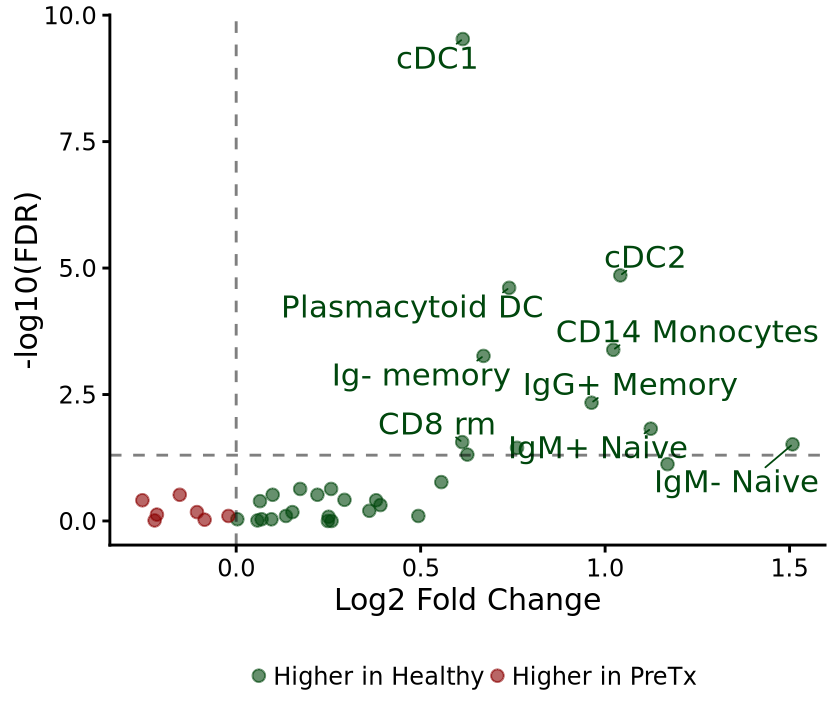

In [4]:
options(repr.plot.width = 7, repr.plot.height = 6)

flow_comparisons$Time <- factor(flow_comparisons$Time, levels = c('PreTx', 'PI2C', 'EI'))

alpha_thresh <- 0.05

# Subset to PreTx and apply the sign flip to be consistent with RNA
plot_data <- flow_comparisons[Time == 'PreTx']
plot_data$Log2FC <- -plot_data$Log2FC

plot_data$Direction <- factor(
  ifelse(plot_data$Log2FC > 0, 'Higher in Healthy', 'Higher in PreTx'),
  levels = c('Higher in Healthy', 'Higher in PreTx')
)
plot_data$sig <- plot_data$FDR < alpha_thresh
plot_data$neglog <- -log10(pmax(plot_data$FDR, .Machine$double.eps))
plot_data$label_wrapped <- stringr::str_wrap(plot_data$Cell, width = 25)

col_map <- c(
  'Higher in Healthy' = tp_colors[['Healthy']],
  'Higher in PreTx'   = tp_colors[['PreTx']]
)

p <- ggplot(plot_data, aes(x = Log2FC, y = neglog, color = Direction, label = label_wrapped)) +
  geom_point(size = 3, alpha = 0.6) +
  ggrepel::geom_text_repel(
    data = subset(plot_data, sig & Cell != 'Neutrophils'),
    size = 6.5,
    max.overlaps = 5,
    min.segment.length = 0,
    show.legend = FALSE
  ) +
  geom_hline(yintercept = -log10(alpha_thresh), linetype = "dashed", alpha = 0.5) +
  geom_vline(xintercept = 0, linetype = "dashed", alpha = 0.5) +
  scale_color_manual(values = col_map, drop = FALSE) +
  labs(
    x = "Log2 Fold Change",
    y = "-log10(FDR)",
    color = NULL
  ) +
  theme_classic(base_size = 18) +
  theme(
    strip.text = element_text(hjust = 0, face = "bold"),
    strip.background = element_blank(),
    legend.position = "bottom",
    legend.text = element_text(margin = margin(r = 10, l = 0)),
    panel.spacing = grid::unit(0.5, "cm")
  )
print(p)

In [5]:
ggsave("../../data/figure-outputs/supplementary-2/sup_2a.pdf",
  plot = p, width = 7, height = 6, dpi = 200,
  device = cairo_pdf
)

Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
